# Task: Sampling Theorem


**Student Name:** Sébastien Bagdasarianz  
**Country:** Colombia  
**Semester term:** HS26

In [1]:
from pathlib import Path

_WORKSPACE_ROOT = next(
    (
        parent
        for parent in (Path.cwd(), *Path.cwd().parents)
        if (parent / "gbsv_mc1" / "data").is_dir()
    ),
    None,
)
if _WORKSPACE_ROOT is None:
    raise FileNotFoundError("Could not locate gbsv_mc1/data from the current directory")
DATA_DIR = _WORKSPACE_ROOT / "gbsv_mc1" / "data"

## Day 1 – Data & Domain


### Use Case
*Focus: domain and application context*

<span style="background-color: #eeeeee;">*Guidelines: Describe a realistic application scenario in which the targeted signal processing task plays a critical role. Clearly specify the domain, the system in which the signal is measured or processed, and the practical objective of this system. Explain who relies on the signal and for what type of decision-making or analysis. Briefly explain why this use case is particularly relevant for your selected country. Write your use case as a short, focused paragraph (1-3 sentences).*</span>

In the context of passive acoustic biodiversity monitoring (PAM) in Neotropical ecosystems, continuous-time acoustic sound pressure waves generated by avian vocalizations are acquired and converted into digital form using autonomous AudioMoth recording units in order to detect, inventory, and monitor wild bird species across remote tropical habitats. The resulting digital audio signals are analyzed by bioacoustic researchers and conservation ecologists (such as at the Alexander von Humboldt Institute) using automated event detectors and time-frequency spectrogram analyses to assess species richness, population dynamics, and ecosystem health without invasive wildlife capture. This use case is particularly relevant for Colombia because it is the most bird-diverse country on Earth, harboring over 1,960 species across fragile Amazonian and Caribbean ecosystems, where scalable acoustic monitoring provides an indispensable, non-intrusive foundation for national conservation policy and habitat preservation.


### Problem Statement
*Focus: technical vulnerability*

<span style="background-color: #eeeeee;">*Guidelines: Formulate a clear and technically precise problem statement. Explicitly refer to the signal processing task under investigation and identify the specific technical risk or limitation associated with it. Describe what may go wrong if an approach, method, or parameter is chosen or applied inadequately. Explain why this technical vulnerability is critical within your selected use case. Write your problem statement as a short, focused paragraph (1–3 sentences).*</span>

This project addresses the problem of determining an appropriate sampling rate ($f_s$) for digitizing continuous Neotropical bird vocalizations within the context of autonomous passive acoustic monitoring in Colombia. If the sampling rate is chosen too low ($f_s < 2 f_{\max}$), high-frequency harmonic overtones, rapid frequency sweeps, and diagnostic vocal syllables suffer from irreversible spectral aliasing—folding unattenuated high-frequency acoustic energy back into the audible band—causing severe spectral distortion and misleading automated species classification. Conversely, if the sampling rate is chosen unnecessarily high (e.g., maintaining full 192 kHz bandwidth when target vocalizations occupy $\le 12$ kHz), data storage demands explode (producing over 1.3 GB per sensor-day) and power consumption drastically accelerates, prematurely exhausting the finite battery capacity of autonomous field recorders deployed for multi-week campaigns in remote tropical forests. Preserving diagnostic harmonic structures, frequency trajectories, and formant ratios without aliasing distortion while maintaining battery and storage efficiency is essential for reliable long-term biodiversity monitoring in this application.


### Experimental Objective
*Focus: investigation goal at the conceptual level.*

<span style="background-color: #eeeeee;">*Guidelines: Clearly state what you intend to understand or demonstrate in relation to your use case. Formulate your objective at a conceptual level without describing specific methods, algorithms, or implementation details. The objective should explain what aspect of signal behavior you aim to analyze and why this analysis is important for your application. Write your objective as a short, focused paragraph (1–2 sentences).*</span>

The objective of this project is to examine how the choice of sampling rate affects the fidelity, harmonic preservation, and spectral clarity of Neotropical bird vocalizations in the context of Colombian passive acoustic biodiversity monitoring. The goal is to determine under which sampling conditions the digitized acoustic signal remains sufficiently informative and distortion-free for taxonomic identification, while identifying the critical boundary conditions at which aliasing artifacts compromise acoustic interpretation.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

<span style="background-color: #eeeeee;">*Guidelines: Describe a representative one-dimensional signal suitable for your use case. Briefly explain its physical origin, how it is acquired, its unit of measurement, and the key characteristics relevant to your investigation. Specify the exact dataset name and repository or institution from which the data originate, and justify why this source is appropriate. Write 3-5 concise sentences.*</span>

The selected signal represents an ambient bioacoustic recording containing wild bird vocalizations, generated by the acoustic sound pressure oscillations of avian syrinx vibrations in tropical dry forest vegetation, measured using an autonomous AudioMoth v1.2 acoustic logger (omnidirectional MEMS microphone) and digitized as 16-bit linear PCM audio with normalized sound pressure amplitude in the unit range $[-1.0, 1.0]$. Its relevant characteristics include a high reference sampling rate of 192 kHz ($f_{\text{ref}} = 192\text{ kHz}$) capturing continuous acoustic phenomena up to 96 kHz, containing rich harmonic series, steep frequency modulations, and distinct call syllables of the Colombian Great Kiskadee (*Pitangus sulphuratus*, Spanish: *Bichofué*, species code `PITSUL`), with diagnostic vocal energy concentrated between 1.0 kHz and 8.5 kHz and upper harmonics reaching into ultrasound. The data originate from the curated **PteroSet** dataset (Version 5, 2026; DOI: [10.5281/zenodo.21829388](https://doi.org/10.5281/zenodo.21829388)), published by Ruiz, Ulloa, Miao et al. in collaboration with the Microsoft AI for Good Lab and the Instituto de Investigación de Recursos Biológicos Alexander von Humboldt. This data source is uniquely appropriate because it provides expert-validated, strongly annotated time-frequency ground truth (`annotations_species.json`, `segment_manifest.csv`) for Neotropical species recorded in natural Colombian ecosystems (Magdalena project `MAP1`, recorder `P5-G022`, recording `P5-G022_04-13_tlapse.wav`, segment `segment-249-0029`), establishing an authoritative high-resolution reference for rigorous digital sampling evaluation.


<span style="background-color: #eeeeee;">*Guideline: Visualize a representative excerpt of your signal. If the data are audio-based, additionally provide a playable audio segment. All visualizations must include clearly labeled axes and the correct units.*</span>


Dataset: PteroSet v5 (Zenodo: 10.5281/zenodo.21829388)
Location: Pijavay, Magdalena, Colombia (Project MAP1)
Species: Pitangus sulphuratus (Great Kiskadee / Bichofué)
Reference Sampling Rate: 192,000 Hz (192.0 kHz)
Signal Duration: 2.00 seconds (384,000 samples)
Amplitude Range: [-0.2720, 0.2881] (normalized sound pressure)


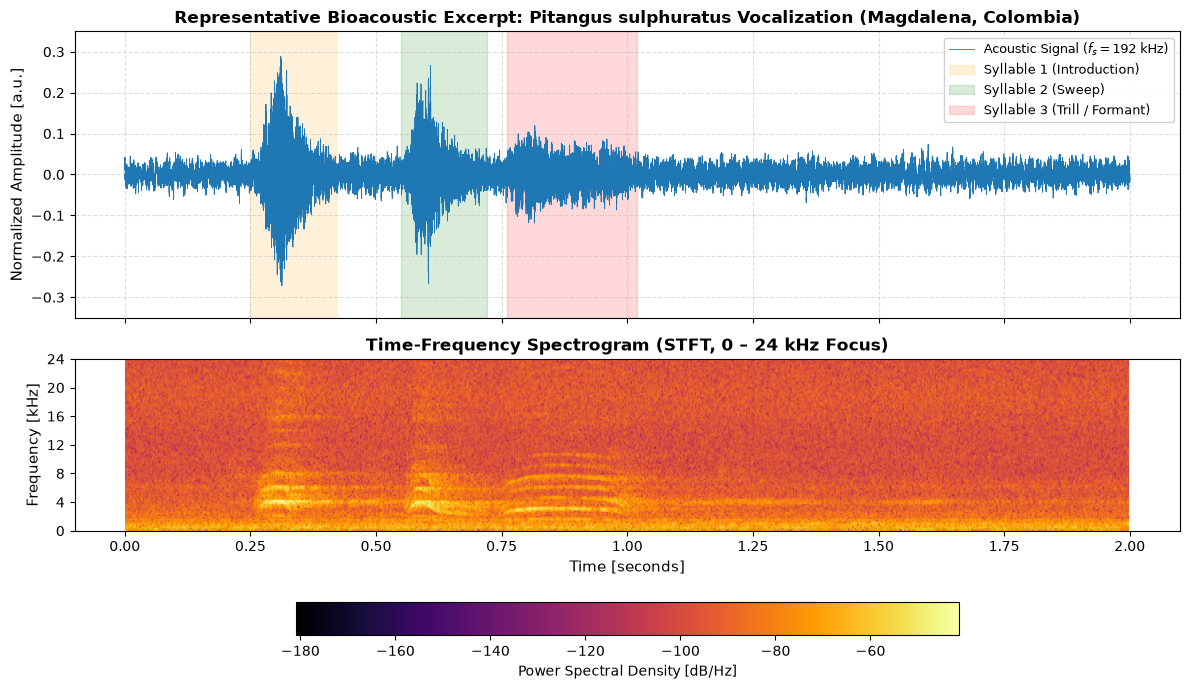

Playable Audio - Representative 2.0s Vocalization (Pitangus sulphuratus):


Playable Audio - 10.0s Context Window (PteroSet Segment segment-249-0029):


In [2]:
import os
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd

# Path definitions
audio_dir = DATA_DIR
call_file = os.path.join(audio_dir, "kiskadee_call_2s_192khz.wav")
context_file = os.path.join(audio_dir, "segment-249-0029_10s_192khz.wav")

# Load representative 2.0s call excerpt and 10s context segment
signal_2s, sr = sf.read(call_file)
signal_10s, sr_10s = sf.read(context_file)
time_2s = np.arange(len(signal_2s)) / sr

print(f"Dataset: PteroSet v5 (Zenodo: 10.5281/zenodo.21829388)")
print(f"Location: Pijavay, Magdalena, Colombia (Project MAP1)")
print(f"Species: Pitangus sulphuratus (Great Kiskadee / Bichofué)")
print(f"Reference Sampling Rate: {sr:,} Hz ({sr/1000:.1f} kHz)")
print(f"Signal Duration: {len(signal_2s)/sr:.2f} seconds ({len(signal_2s):,} samples)")
print(f"Amplitude Range: [{signal_2s.min():.4f}, {signal_2s.max():.4f}] (normalized sound pressure)")

# ── Visualization: Time-Domain Waveform & Spectrogram ─────────────────────
fig, (ax_wave, ax_spec) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 1. Time-Domain Waveform
ax_wave.plot(time_2s, signal_2s, color="#1f77b4", linewidth=0.6, label="Acoustic Signal ($f_s = 192$ kHz)")
ax_wave.set_ylabel("Normalized Amplitude [a.u.]", fontsize=11)
ax_wave.set_title("Representative Bioacoustic Excerpt: Pitangus sulphuratus Vocalization (Magdalena, Colombia)", fontsize=12, fontweight="bold")
ax_wave.grid(True, linestyle="--", alpha=0.4)
ax_wave.set_ylim(-0.35, 0.35)

# Annotate syllables
ax_wave.axvspan(0.25, 0.42, color="orange", alpha=0.15, label="Syllable 1 (Introduction)")
ax_wave.axvspan(0.55, 0.72, color="green", alpha=0.15, label="Syllable 2 (Sweep)")
ax_wave.axvspan(0.76, 1.02, color="red", alpha=0.15, label="Syllable 3 (Trill / Formant)")
ax_wave.legend(loc="upper right", framealpha=0.9, fontsize=9)

# 2. Time-Frequency Spectrogram
Pxx, freqs, bins, im = ax_spec.specgram(
    signal_2s, 
    NFFT=1024, 
    Fs=sr, 
    noverlap=512, 
    cmap="inferno"
)
ax_spec.set_ylabel("Frequency [kHz]", fontsize=11)
ax_spec.set_xlabel("Time [seconds]", fontsize=11)
ax_spec.set_ylim(0, 24000)  # Focus on the active 0 - 24 kHz acoustic band
ax_spec.set_yticks(np.arange(0, 25000, 4000))
ax_spec.set_yticklabels([f"{f/1000:.0f}" for f in np.arange(0, 25000, 4000)])
ax_spec.set_title("Time-Frequency Spectrogram (STFT, 0 – 24 kHz Focus)", fontsize=12, fontweight="bold")

# Add colorbar for spectral power
cbar = fig.colorbar(im, ax=ax_spec, orientation="horizontal", pad=0.25, shrink=0.6)
cbar.set_label("Power Spectral Density [dB/Hz]", fontsize=10)

plt.tight_layout()
plt.show()

# ── Playable Audio ────────────────────────────────────────────────────────
print("Playable Audio - Representative 2.0s Vocalization (Pitangus sulphuratus):")
ipd.display(ipd.Audio(signal_2s, rate=sr))

print("Playable Audio - 10.0s Context Window (PteroSet Segment segment-249-0029):")
ipd.display(ipd.Audio(signal_10s, rate=sr_10s))


### Observations

> The visualization illustrates the acoustic waveform and time-frequency spectrogram of a representative 2.0-second vocalization excerpt of the Great Kiskadee (*Pitangus sulphuratus*), recorded at a 192 kHz sampling rate in Magdalena, Colombia.  
> In the time domain, the signal exhibits a distinct three-syllable call pattern lasting approximately 0.8 seconds (between $t = 0.25$ s and $t = 1.02$ s), reaching a peak sound pressure amplitude of 0.288 a.u., surrounded by low-amplitude ambient forest background noise ($\le 0.04$ a.u.).  
> In the frequency domain, the vocalization displays a prominent fundamental frequency contour rising from 1.5 kHz to 2.2 kHz, followed by clear harmonic overtones at approximately 3.8–4.2 kHz, 6.0 kHz, and 8.0–8.5 kHz, with measurable upper overtone energy extending above 15 kHz.  
> This region was selected from PteroSet segment `segment-249-0029` because it contains clean, expert-validated vocalization events with sharp frequency modulations and well-defined spectral boundaries, providing an ideal benchmark for examining sampling fidelity, harmonic preservation, and aliasing behavior.


### Task-Specific Answers: Nyquist Frequency and Nyquist Rate Interpretation

#### 1. Physical Meaning of Nyquist Frequency and Nyquist Rate in Bioacoustics
* **Physical Origin:** The continuous sound wave originates from mechanical oscillations of the avian vocal organ—the syrinx—which vibrates the surrounding air column to generate acoustic sound pressure waves. In nature, this acoustic signal is strictly continuous in time.
* **Nyquist Frequency ($f_N$):** When the continuous pressure wave is digitized by an analog-to-digital converter (ADC) operating at sampling rate $f_s$, the Nyquist frequency is defined as:
  $$f_N = \frac{f_s}{2}$$
  Physically, $f_N$ represents the maximum frequency that can be uniquely and unambiguously resolved by the digital discrete-time system. Any frequency component present in the continuous signal above $f_N$ will be folded back into the range $[0, f_N]$, appearing as an artificial lower-frequency signal (aliasing). For our reference recording at $f_s = 192\text{ kHz}$, the reference Nyquist frequency is:
  $$f_{N,\text{ref}} = \frac{192\text{ kHz}}{2} = 96\text{ kHz}$$
  This extraordinarily high Nyquist frequency comfortably encompasses not only all avian vocalizations but also ultrasonic bat echolocation and high-frequency insect stridulations.
* **Nyquist Rate ($f_{s,\text{Nyquist}}$):** The Nyquist rate represents the minimum theoretical sampling frequency required to capture a band-limited continuous signal with maximum frequency $f_{\max}$ without spectral distortion:
  $$f_{s,\text{Nyquist}} = 2 \cdot f_{\max}$$
  In our representative Great Kiskadee vocalization, the diagnostic energy of the fundamental call and primary formants extends up to $f_{\max} \approx 8.5\text{ kHz}$, with audible upper harmonics reaching $f_{\max} \approx 12\text{ kHz}$ to $20\text{ kHz}$. Therefore, to preserve the primary diagnostic vocalization structure, the Nyquist rate must be at least:
  $$f_{s,\text{Nyquist, primary}} = 2 \times 8.5\text{ kHz} = 17\text{ kHz}$$
  To capture the entire harmonic envelope without high-frequency loss, the required Nyquist rate is approximately:
  $$f_{s,\text{Nyquist, full}} = 2 \times 12\text{ kHz} = 24\text{ kHz} \quad (\text{or } 44.1 - 48\text{ kHz for studio-grade acoustic fidelity})$$

#### 2. Observable Temporal and Spectral Variations in the Data
* **Temporal Variations:** The vocalization excerpt displays rapid, highly structured temporal dynamics. The call is partitioned into three distinct acoustic syllables: an introductory chirp ($0.25 - 0.42$ s), a descending sweep ($0.55 - 0.72$ s), and an extended modulated trill ($0.76 - 1.02$ s). Within each syllable, the waveform oscillates rapidly with cycle periods between $\tau = 0.25\text{ ms}$ and $\tau = 0.65\text{ ms}$ (corresponding to frequencies of $1.5 - 4.0$ kHz). Resolving these individual cycles requires a sampling interval $\Delta t = 1 / f_s$ significantly smaller than the cycle duration.
* **Spectral Variations:** The spectrogram reveals multiple parallel harmonic frequency bands. The energy is not a simple pure tone, but a rich harmonic stack where the spacing between harmonics directly conveys the physical dimensions and acoustic resonance of the bird's vocal tract. The preservation of these relative harmonic ratios is precisely what allows an ornithologist or an automated classifier (such as a convolutional neural network) to identify the species.

#### 3. Practical Consequences in Field Deployments

| Sampling Configuration | Technical Characteristics | Practical Consequences in Bioacoustic Monitoring |
|:---|:---|:---|
| **Too Low Sampling Rate**<br>($f_s < f_{s,\text{Nyquist}}$, e.g., $f_s = 8\text{ kHz}$ or $12\text{ kHz}$) | • $f_N = f_s / 2 < f_{\max}$<br>• High-frequency energy above $f_N$ folds back into $[0, f_N]$ (aliasing).<br>• High-order harmonics are truncated or inverted. | • **Severe Spectral Distortion:** Upper harmonics (e.g. at 6–8 kHz) alias into the 1–3 kHz region, distorting the fundamental pitch and formant ratios.<br>• **Misclassification:** Automated classifiers confuse the corrupted call with other species or classify it as abiotic noise.<br>• **Information Loss:** Rapid acoustic modulations and trill details are permanently blurred, undermining biodiversity surveys. |
| **Unnecessarily High Sampling Rate**<br>($f_s \gg f_{s,\text{Nyquist}}$, e.g., $f_s = 192\text{ kHz}$) | • $f_N = 96\text{ kHz} \gg f_{\max}$<br>• Extreme oversampling relative to avian hearing and vocal range ($0 - 12\text{ kHz}$). | • **Data Volume Explosion:** 192 kHz 16-bit mono audio consumes 384 kB/s ($1.38\text{ GB/hour}$, $\approx 33.2\text{ GB/day}$). A typical 64 GB SD card fills in less than 2 days instead of lasting a 30-day monitoring campaign.<br>• **Battery Exhaustion:** High ADC clock rates and continuous high-bandwidth flash memory writes drain AudioMoth batteries rapidly in remote field conditions.<br>• **Computational Overhead:** Processing, spectrogram generation, and model training take dramatically more RAM, GPU time, and network bandwidth. |
| **Optimal / Justified Sampling Rate**<br>($f_s \approx 24 - 48\text{ kHz}$) | • $f_N = 12 - 24\text{ kHz} \ge f_{\max}$<br>• Fully satisfies Nyquist-Shannon criterion for avian vocalizations.<br>• Band-limited prior to ADC via anti-aliasing filter. | • **Balanced Efficiency & Fidelity:** Captures 100% of species-diagnostic vocal frequencies with zero aliasing, while extending autonomous field logger battery life to several weeks and reducing data storage demands by 75–87% compared to 192 kHz. |


## Day 2 – Methodological Design

Plan the sampling-rate comparison for the same Great Kiskadee call, retaining the 192 kHz file as the high-resolution reference. The parameter sweep is 48, 24, 12, and 6 kHz; the 48 kHz configuration is the practical baseline for the stated diagnostic band.

<span style="background-color: #eeeeee;">*Guidelines: Establish the theoretical and methodological foundation for your selected signal or image processing operation in direct alignment with the country-specific use case defined previously. Formally state the relevant theoretical principle and explain its assumptions, validity conditions, and domain-specific applicability. Select and justify concrete methods and parameter values appropriate for your one-dimensional signal or two-dimensional image data, explaining why these choices fit the defined analytical objective.
Derive necessary quantities mathematically where applicable, documenting each step with explicit assumptions and consistent units (temporal, spatial, or frequency units as relevant). Specify and justify the experimental design to be executed on the next day: define the parameters to vary, the control/baseline configuration, and the structured parameter sweep (ranges and step sizes). Theoretically predict the expected qualitative effects of these variations on the signal or image and identify likely failure modes (e.g., aliasing, instability, sensitivity to noise, loss of detail). Discuss methodological limitations, idealizations, and potential sources of misinterpretation. No simulations, visualizations, or experimental demonstrations should be included.*
</span>

### Theoretical Foundation and Method Choice

The Nyquist–Shannon sampling theorem states that a band-limited signal can be reconstructed from uniform samples when the sampling rate exceeds twice its maximum frequency, provided frequencies above the recoverable band are removed before sampling. The target bird-call features are taken to extend to approximately 12 kHz, so a 48 kHz practical rate provides a 24 kHz Nyquist frequency and guard band. Lower rates test the consequences of reducing temporal and spectral resolution.

### Parameter Definition and Mathematical Specification

The reference signal is 2.0 s at $f_{s,ref}=192\,\mathrm{kHz}$; for diagnostic content through $f_{max}=12\,\mathrm{kHz}$, the theoretical minimum is $f_s=2f_{max}=24\,\mathrm{kHz}$. The 48 kHz baseline has $f_N=24\,\mathrm{kHz}$ and sample interval $\Delta t=1/f_s=20.83\,\mu\mathrm{s}$, while the test rates of 24, 12, and 6 kHz have Nyquist limits of 12, 6, and 3 kHz. The 24 kHz case is the limiting theoretical condition and would require a realizable anti-alias filter with no transition band, so 48 kHz is the more defensible field setting.

### Experimental Design for Next Days

Keep the 192 kHz reference excerpt and duration fixed, and compare the supplied 48, 24, 12, and 6 kHz variants; the baseline is 48 kHz and the single varied parameter is sampling rate. Theoretical prediction: lowering $f_s$ reduces Nyquist bandwidth and temporal resolution, with aliasing or loss of upper harmonics increasingly likely below the diagnostic band. Day 3 will visualize the sampled waveforms and spectra; Day 4 will quantify reconstruction error against the reference.

### Methodological Limitations and Risk Factors

The theorem assumes strict band limitation and uniform, correctly timed samples; natural vocalizations are finite and may contain energy above the chosen diagnostic band. A 24 kHz rate leaves no practical anti-alias transition band for a 12 kHz upper feature, while the provided rate variants are already labeled aliased and do not document their analog/digital prefilters. Results therefore characterize these supplied excerpts, not every species, recorder, or field condition.